In [46]:
import matplotlib.pyplot as plt
from electro.dsp import signals as sig
from electro.dsp import spectral as fft
from electro.dsp import filters as fil
from electro.graphics import plot
import numpy as np

# Example Filters
---

In [47]:
# Example parameters
N = 32          # filter order
C = 2           # cascaded stages
fs = N          # normalized sampling frequency
L = 1           # interpolation factor

length = 512    # length of impulse

impulse = sig.kronecker_delta(length)

## Pasabajos Recursivo de Lyons

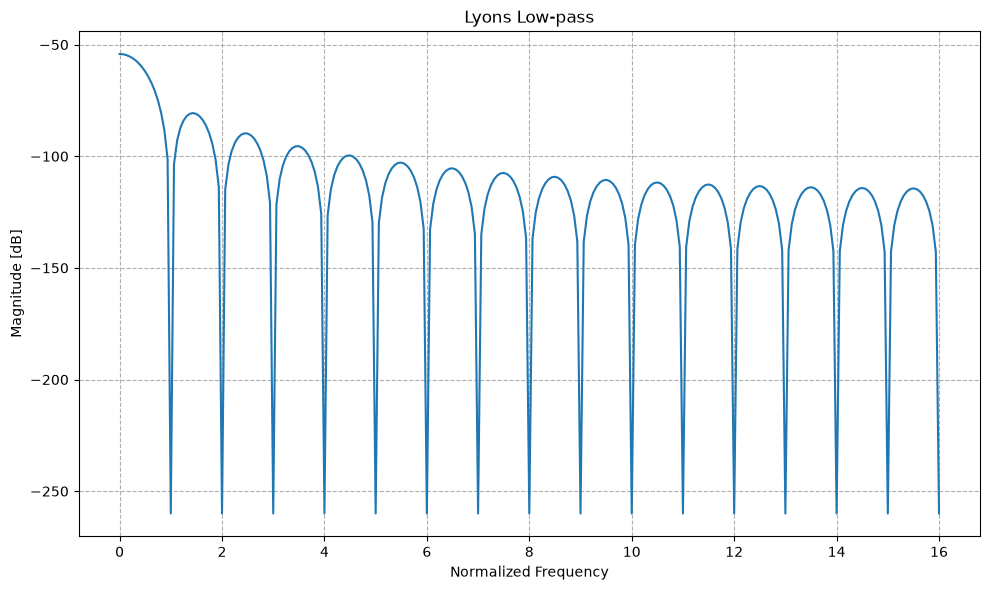

In [48]:
f = fft.fft_freq(length, fs, only_positive=True)

# Apply filters
low = fil.lyons_lowpass(impulse, N, C)
spec_low = fft.fft(low, only_positive=True)

# --- Plot ---
plt.figure(figsize=(10,6))
plot.plot_mag(f, spec_low)
plt.title(f"Lyons Low-pass")
plt.xlabel("Normalized Frequency")
plt.ylabel("Magnitude [dB]")
plt.grid(True)

plt.tight_layout()
plt.show()


## Pasaltos Recursivo de Lyons

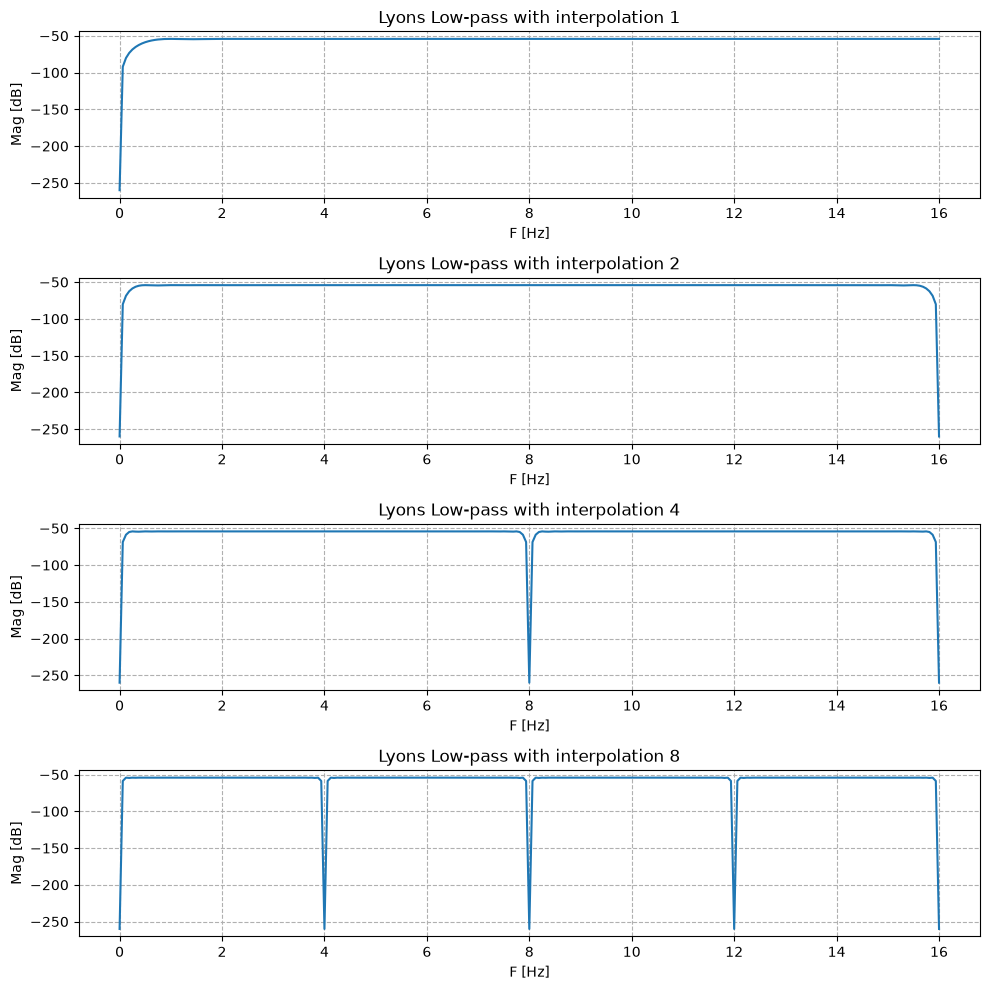

In [49]:
L = [1, 2, 4, 8]

f = fft.fft_freq(length, fs, only_positive=True)

plt.figure(figsize=(10,10))
for i, l in enumerate(L, start=1):
    # Apply filters
    high = fil.lyons_highpass(impulse, N, C, interpolation=l)
    spec_high = fft.fft(high, only_positive=True)
    # --- Plot ---
    plt.subplot(len(L), 1, i)
    plot.plot_mag(f, spec_high)
    plt.title(f"Lyons Low-pass with interpolation {l}")
    plt.xlabel("F [Hz]")
    plt.ylabel("Mag [dB]")
    plt.grid(True)

plt.tight_layout()
plt.show()


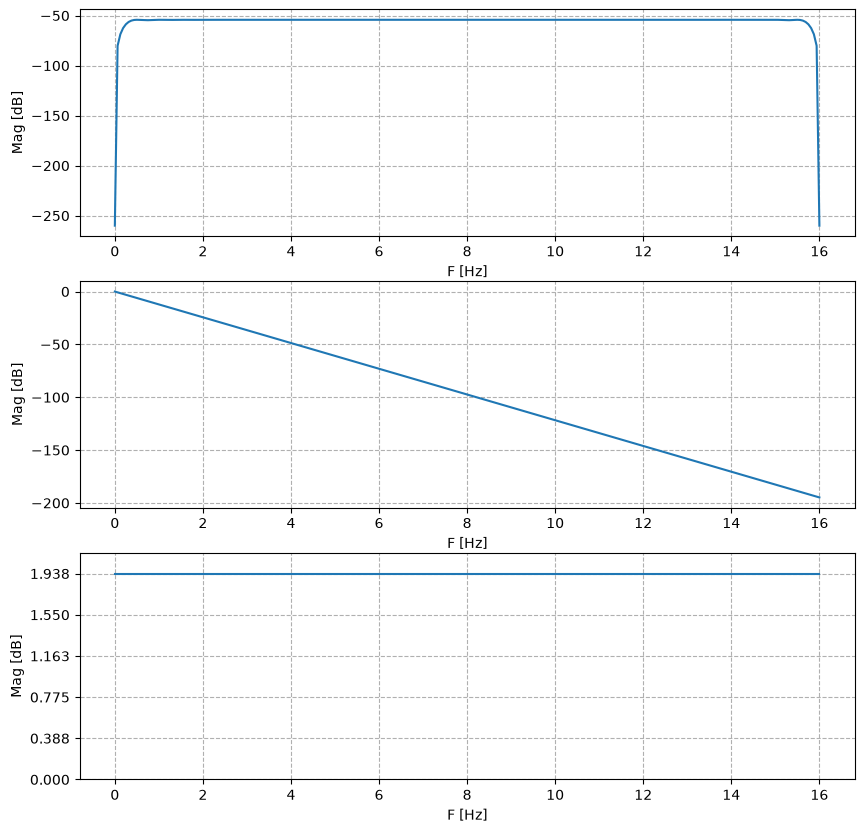

delay del filtro de lyons: 1.9375


In [50]:
L = 2
f = fft.fft_freq(length, fs, only_positive=True)
high = fil.lyons_highpass(impulse, N, C, interpolation=L)
spec_high = fft.fft(high, only_positive=True)

delay = fil.delay_lyons_filter(N, C, interpolation=L, fs=fs)

plt.figure(figsize=(10,10))
plt.subplot(3,1,1)
plot.plot_mag(f, spec_high)
plt.xlabel("F [Hz]")
plt.ylabel("Mag [dB]")

plt.subplot(3,1,2)
plot.plot_phase(f, spec_high)
plt.xlabel("F [Hz]")
plt.ylabel("Mag [dB]")

plt.subplot(3,1,3)
plot.plot_delay(f, spec_high)
plt.xlabel("F [Hz]")
plt.ylabel("Mag [dB]")
plt.ylim((0, delay * 1.1))
plt.yticks(np.arange(0, delay*1.1, delay/5))
plt.show()

print(f"delay del filtro de lyons: {delay}")

## Promedio ventaneado con interpolación

Responde igual al filtro pasabajos del lyons. En el fondo solo es un promediador

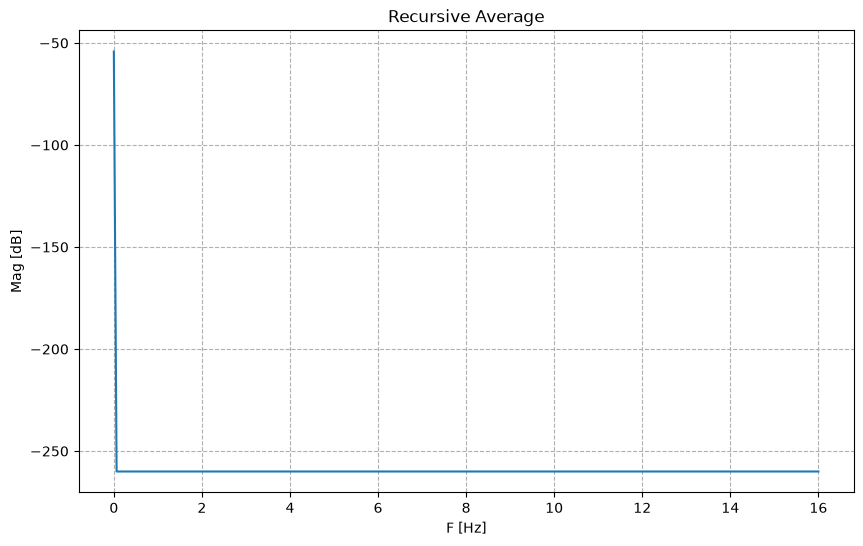

In [51]:
# Recursive moving average 
movavg = fil.recursive_moving_average(impulse, length)
spec_movavg = fft.fft(movavg, only_positive=True)

plt.figure(figsize=(10,6))
plot.plot_mag(f, spec_movavg)
plt.title("Recursive Average")
plt.xlabel("F [Hz]")
plt.ylabel("Mag [dB]")
plt.grid(True)
plt.show()


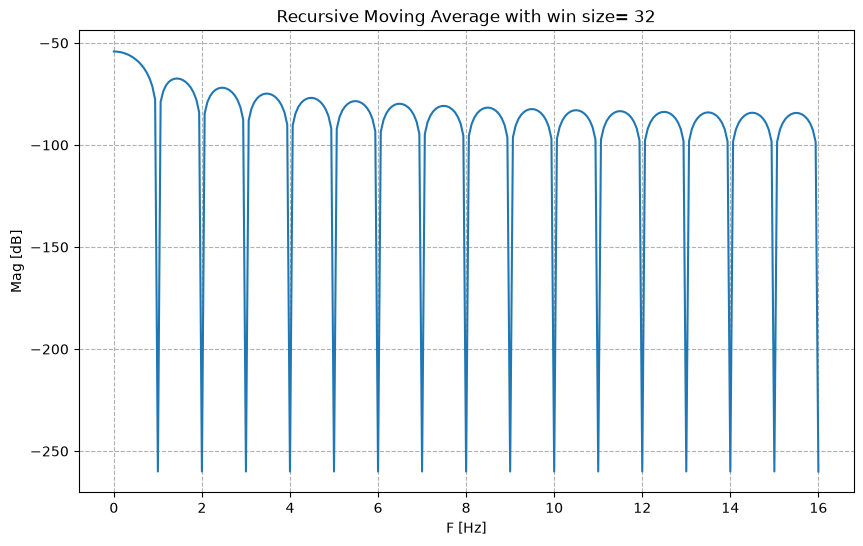

In [52]:
# Recursive moving average 
movavg = fil.recursive_moving_average(impulse, N)
spec_movavg = fft.fft(movavg, only_positive=True)

plt.figure(figsize=(10,6))
plot.plot_mag(f, spec_movavg)
plt.title(f"Recursive Moving Average with win size= {N}")
plt.xlabel("F [Hz]")
plt.ylabel("Mag [dB]")
plt.grid(True)
plt.show()
